### GFS sampling paper plot

In [66]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
import numpy as np
import matplotlib.pyplot as plt
import graphical_sampling as gs
from graphical_sampling.index import Moran

In [68]:
# --- Population ---
coords_data = np.array([
    (1,1),(1,2),(1,3),
    (2,1),(2,2),(2,3),
    (3,1),(3,2),(3,3)
])

inclusions_data = np.array([0.7, 0.3, 0.4, 0.8, 0.3, 0.65, 0.45, 0.2, 0.2])
n = int(inclusions_data.sum())

pop = gs.Population(coords_data, inclusions_data, n=n, variable=inclusions_data)

# --- Clustering ---
fbn = gs.clustering.FIPBalancedNMeans(
    n=n,
    centroid_grid_x=1,
    r_sample_per_cluster=1,
    init_clust_method='expanded',
    split_size=.001
)

fbn.fit(pop)
fbn.fit_zones(num_zones=(1,1), mode='sweep_yx')

# --- Order & Design ---
order = gs.Order.from_clusters(
    pop,
    fbn.clusters,
    zone_strategy='lexico_yx',
    point_strategy='lexico_yx',
    num_splits=1,
    topological=True
)

design = gs.Design.from_order(pop, order)


Sample: [1 3 5 7]
Moran(sample): -0.9087389347953035


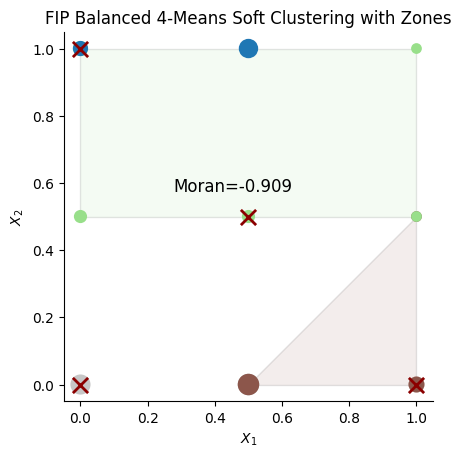

In [69]:

# =========================================================
# 🔴 STEP 1: draw ONE sample from the design
# =========================================================
sample = design.sample(1)[0]
sample = np.array([1,3,5,7]) -1  # shape (n,)
print("Sample:", sample+1)

# =========================================================
# 🔴 STEP 2: Moran for THIS sample (not expected value)
# =========================================================
moran_index = Moran(pop)
moran_val = moran_index.score(np.array([sample]))[0]

print("Moran(sample):", moran_val)

# =========================================================
# 🔴 STEP 3: Plot
# =========================================================
fig, ax = plt.subplots()

# background clusters
fbn.plot(mode='soft', ax=ax)

coords = pop.coords

# highlight selected units
ax.scatter(coords[sample, 0], coords[sample, 1],
           color="darkred", marker='x', s=120, linewidths=2, zorder=10)

# label
x, y = coords[sample].mean(axis=0)
ax.text(x-0.1, y+0.2, f"Moran={moran_val:.3f}", fontsize=12)

plt.show()

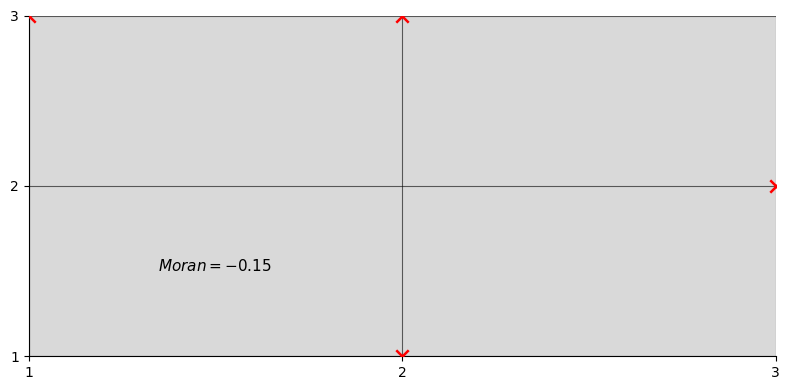

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from graphical_sampling.index import Moran
coords_data = np.array([
    (1,1),(1,2),(1,3),
    (2,1),(2,2),(2,3),
    (3,1),(3,2),(3,3)
])
coords = coords_data
sample = design.sample(1)[0]

# Moran
moran_index = Moran(pop)
moran_val = moran_index.score(np.array([sample]))[0]

# =========================================================
# 🔴 Figure (match your style)
# =========================================================
fig, ax = plt.subplots(figsize=(8, 4))

# --- background ---
ax.set_facecolor("#d9d9d9")   # light gray panel
# --- grid lines (only internal structure) ---
x_vals = np.unique(coords[:,0])
y_vals = np.unique(coords[:,1])

for x in x_vals:
    ax.axvline(x, color='black', lw=0.8, alpha=0.6, zorder=0)

for y in y_vals:
    ax.axhline(y, color='black', lw=0.8, alpha=0.6, zorder=0)

# --- sample (crosses only, no population dots) ---
ax.scatter(coords[sample, 0], coords[sample, 1],
           color="red", marker='x', s=80, linewidths=1.8, zorder=5)

# --- ticks exactly like figure ---
ax.set_xticks(x_vals)
ax.set_yticks(y_vals)

# --- limits tight ---
ax.set_xlim(x_vals.min(), x_vals.max())
ax.set_ylim(y_vals.min(), y_vals.max())

# --- clean axes ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Moran annotation (subtle, like your figure) ---
ax.text(1.5, y_vals.min()+0.5,
        rf"$Moran={moran_val:.2f}$",
        ha='center', fontsize=11)

plt.tight_layout()
plt.show()

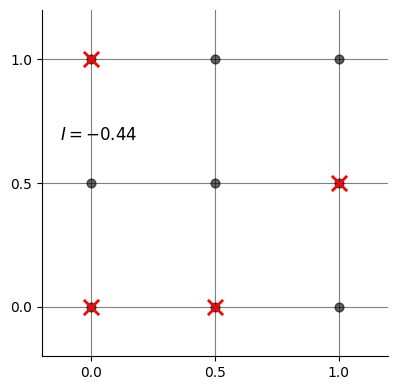

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from graphical_sampling.index import Moran

# --- coords & sample already defined ---
coords = pop.coords

# --- sample ---
sample = design.sample(1)[0]

# --- Moran ---
moran_index = Moran(pop)
moran_val = moran_index.score(np.array([sample]))[0]

# =========================================================
# 🔴 Manual plotting
# =========================================================
fig, ax = plt.subplots(figsize=(6, 4))

# --- population points (light) ---
ax.scatter(coords[:, 0], coords[:, 1],
           color="black", s=40, alpha=0.6, zorder=1)

# --- sample (crosses) ---
ax.scatter(coords[sample, 0], coords[sample, 1],
           color="red", marker='x', s=120, linewidths=2, zorder=3)

# --- optional: grid lines (like your figure) ---
for x in np.unique(coords[:,0]):
    ax.axvline(x, color='black', lw=0.8, alpha=0.5, zorder=0)

for y in np.unique(coords[:,1]):
    ax.axhline(y, color='black', lw=0.8, alpha=0.5, zorder=0)

# --- limits & ticks ---
ax.set_xlim(coords[:,0].min()-0.2, coords[:,0].max()+0.2)
ax.set_ylim(coords[:,1].min()-0.2, coords[:,1].max()+0.2)

ax.set_xticks(np.unique(coords[:,0]))
ax.set_yticks(np.unique(coords[:,1]))

# --- Moran text ---
x_mean, y_mean = coords[sample].mean(axis=0)
ax.text(x_mean-0.5, y_mean+0.3,
        rf"$I={moran_val:.2f}$",
        fontsize=12)

# --- style (paper-like) ---
ax.set_aspect('equal')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### For sampling

In [72]:
import os
os.getcwd()
# os.chdir("/home/bardia/graphical-sampling")
# os.chdir("/home/bardia/graphical-sampling/simulations")
# os.chdir('/config/ws/graphical-sampling/simulations')
os.chdir('/Users/Apc/graphical-sampling/simulations')
from package_sampling.utils import inclusion_probabilities

import os
import pandas as pd
import numpy as np

# Assuming inclusion_probabilities is defined elsewhere or imported
# from your package
files = ["aggregated.csv", "regular.csv", "meuse.csv", "swiss.csv", "aggregated_1000.csv", "regular_1000.csv",
         "AggregatedPop1000.csv", "RegularPop1000.csv"]

def popus(n, path="populations/real"):
    dfs = {} # Better to define inside to keep it clean
    for f in files:
        full_path = os.path.join(path, f)
        if not os.path.exists(full_path):
            print(f"Warning: {full_path} not found.")
            continue
            
        df = pd.read_csv(full_path)
        N_pop = len(df)
        name = f.replace('.csv', '')
        
        # Equal Probabilities (Standard for all)
        pik_ep = np.repeat(n / N_pop, N_pop)
        
        if f in ["aggregated.csv", "regular.csv",  "aggregated_1000.csv", "regular_1000.csv",
                  "AggregatedPop1000.csv", "RegularPop1000.csv"]:
            coords = df.to_numpy()
            dfs[f'df_{name}'] = pd.DataFrame({
                'coord_x': coords[:, 0],
                'coord_y': coords[:, 1],
                'pik_ep' : pik_ep,
                'z'      : np.ones(N_pop) # Placeholder if z is missing
            })

        elif f == "meuse.csv":
            coords = df[['x', 'y']].to_numpy()
            # Unequal Probabilities (UP)
            pik_up = inclusion_probabilities(df['copper'].to_numpy().copy(), n)
            dfs[f'df_{name}'] = pd.DataFrame({
                'coord_x': coords[:, 0],
                'coord_y': coords[:, 1],
                'pik_ep' : pik_ep,
                'pik_up' : pik_up,
                'z'      : df['cadmium']
            })

        elif f == "swiss.csv":
            coords = df[['x', 'y']].to_numpy()
            AREA = df['AREA'].to_numpy().clip(5, 100)
            pik_up = inclusion_probabilities(AREA.copy(), n)
            dfs[f'df_{name}'] = pd.DataFrame({
                'coord_x': coords[:, 0],
                'coord_y': coords[:, 1],
                'pik_ep' : pik_ep,
                'pik_up' : pik_up,
                'z'      : df['AREA_A']
            })
            
    return dfs

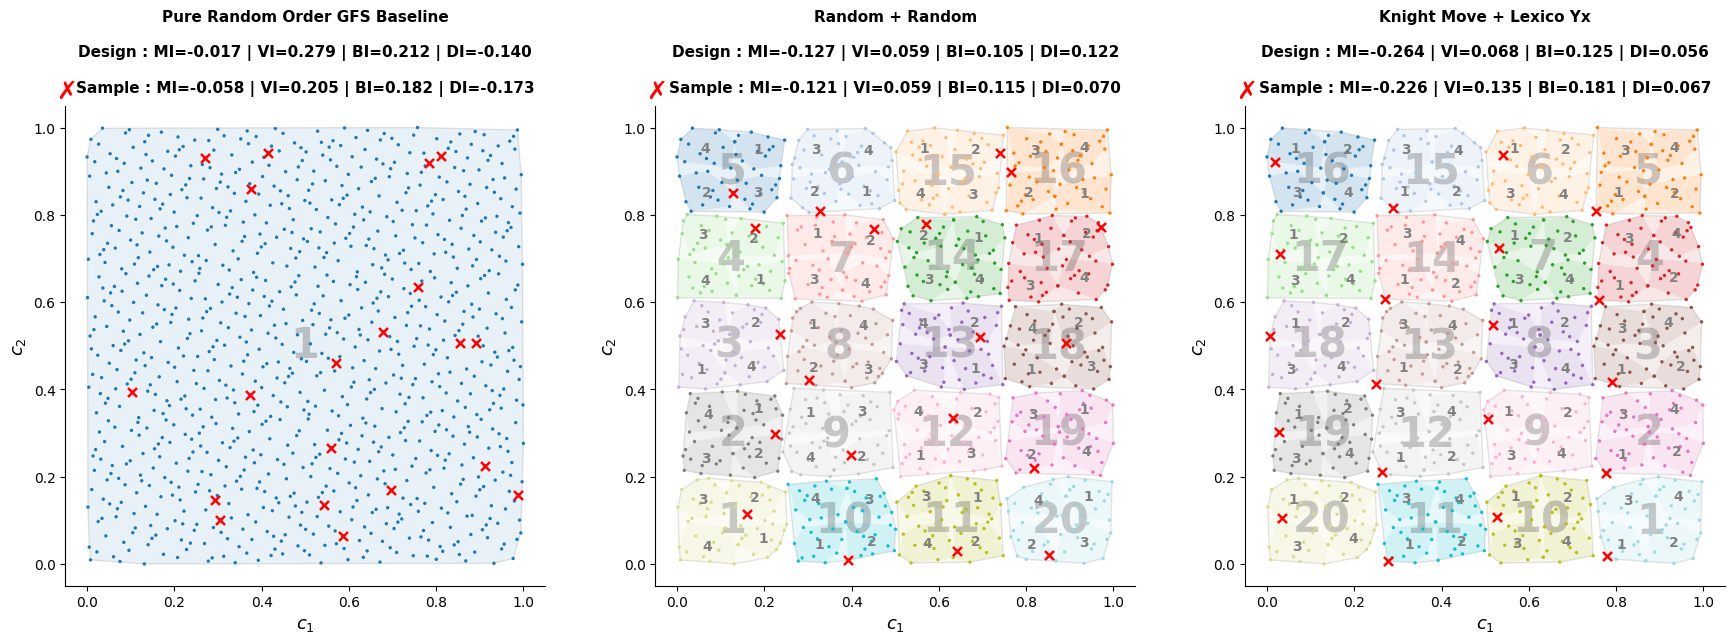

In [73]:
import matplotlib.pyplot as plt
import numpy as np
import graphical_sampling as gs

from graphical_sampling.index import (
    DensityDisparity,
    Moran,
    Voronoi,
    LocalBalance
)

# =========================================================
# PARAMETERS
# =========================================================
popu = 'df_RegularPop1000'
ep_or_up = 'pik_ep'
n = 20

df = popus(n)[popu]

coords_data = df[['coord_x', 'coord_y']].to_numpy()
inclusions_data = df[ep_or_up].to_numpy()
variable_data = df['z'].to_numpy()

pop = gs.Population(
    coords_data,
    inclusions_data,
    n=n,
    variable=variable_data
)

# =========================================================
# CONFIGURATIONS
# =========================================================
configs = [

    # -----------------------------------------------------
    # CONFIG 1 : PURE RANDOM BASELINE
    # -----------------------------------------------------
    dict(
        point_strategy='random',
        zone_strategy='random',
        zone_mode='sweep_yx',
        num_zones=(1,1),
        centroid_grid_x=1,
        r_sample_per_cluster=20,
        title='Random GFS Baseline'
    ),

    # -----------------------------------------------------
    # CONFIG 2
    # -----------------------------------------------------
    dict(
    point_strategy='random',
    zone_strategy='random',
    zone_mode='sweep_yx',
    num_zones=(2,2),
    centroid_grid_x=4,
    r_sample_per_cluster=1,
),

# -----------------------------------------------------
# CONFIG 3
# -----------------------------------------------------
dict(
    point_strategy='knight_move',
    zone_strategy='lexico',
    zone_mode='sweep_yx',
    num_zones=(2,2),
    centroid_grid_x=4,
    r_sample_per_cluster=1,
)
]
# =========================================================
# AUTOMATIC TITLES
# =========================================================
for cfg in configs:

    if cfg['r_sample_per_cluster'] == 20:
        cfg['title'] = 'Pure Random Order GFS Baseline'
    else:
        cfg['title'] = (
            f"{cfg['point_strategy'].replace('_', ' ').title()} + "
            f"{cfg['zone_strategy'].replace('_', ' ').title()}"
        )
# =========================================================
# FIGURE
# =========================================================
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6),
    gridspec_kw={'wspace': 0.01}
)

# =========================================================
# MAIN LOOP
# =========================================================
for ax, cfg in zip(axes, configs):

    # -----------------------------------------------------
    # CLUSTERING
    # -----------------------------------------------------
    fbn = gs.clustering.FIPBalancedNMeans(
        n=n,
        centroid_grid_x=cfg['centroid_grid_x'],
        r_sample_per_cluster=cfg['r_sample_per_cluster'],
        init_clust_method='expanded',
        split_size=1
    )

    fbn.fit(pop)

    fbn.fit_zones(
        num_zones=cfg['num_zones'],
        mode=cfg['zone_mode']
    )

    # -----------------------------------------------------
    # ORDER
    # -----------------------------------------------------
    order = gs.Order.from_clusters(
        pop,
        fbn.clusters,
        zone_strategy=cfg['zone_strategy'],
        point_strategy=cfg['point_strategy'],
        num_splits=1,
        topological=True,
        shift_jump=2,
        shuffle=False,
        grid_dims=cfg['num_zones']
    )

    # synchronize plotting order
    fbn.clusters = order.clusters

    # -----------------------------------------------------
    # DESIGN
    # -----------------------------------------------------
    design = gs.Design.from_order(pop, order)

    coords = design.pop.coords

    # -----------------------------------------------------
    # BACKGROUND
    # -----------------------------------------------------
    fbn.plot(
        mode='soft',
        ax=ax,
        show_zone_sub_hulls=True,
        show_zone_labels=True
    )

    # -----------------------------------------------------
    # CLUSTER LABELS
    # -----------------------------------------------------
    for i, cluster in enumerate(fbn.clusters):

        cluster_points = []

        for zone in cluster.zones:
            cluster_points.extend(zone.indices)

        cluster_points = np.array(cluster_points)

        centroid = coords[cluster_points].mean(axis=0)

        ax.text(
            centroid[0],
            centroid[1],
            f"{i+1}",
            fontsize=30,
            color='black',
            alpha=0.20,
            ha='center',
            va='center',
            weight='bold',
            zorder=1
        )

    # -----------------------------------------------------
    # SAMPLE
    # -----------------------------------------------------
    sample_indices_2d = design.sample(1)
    sample_indices = sample_indices_2d[0]

    # -----------------------------------------------------
    # SAMPLE INDICES
    # -----------------------------------------------------
    mi_s = Moran(pop, method='tille').score(sample_indices_2d)[0]

    vi_s = Voronoi(pop).score(sample_indices_2d)[0]

    bi_s = LocalBalance(pop).score(sample_indices_2d)[0]

    di_s = DensityDisparity(pop).score(sample_indices_2d)[0]

    # -----------------------------------------------------
    # EXPECTED INDICES
    # -----------------------------------------------------
    mi_e = design.moran[0]

    vi_e = design.voronoi[0]

    bi_e = design.local_balance[0]

    di_e = design.density_disparity[0]

    # -----------------------------------------------------
    # SAMPLE POINTS
    # -----------------------------------------------------
    ax.scatter(
        coords[sample_indices, 0],
        coords[sample_indices, 1],
        marker='x',
        color='red',
        s=42,
        linewidths=1.8,
        zorder=20
    )

    # -----------------------------------------------------
    # TITLE
    # -----------------------------------------------------
    title = (
        f"{cfg['title']}\n\n"
        # f"ZS={cfg['zone_strategy']} | "
        # f"PS={cfg['point_strategy']} | "
        # f"Mode={cfg['zone_mode']} | "
        # f"Zones={cfg['num_zones']}\n\n"
        f"Design : "
        f"MI={mi_e:.3f} | "
        f"VI={vi_e:.3f} | "
        f"BI={bi_e:.3f} | "
        f"DI={di_e:.3f}\n\n"
        r"Sample : "
        f"MI={mi_s:.3f} | "
        f"VI={vi_s:.3f} | "
        f"BI={bi_s:.3f} | "
        f"DI={di_s:.3f}"
    )

    ax.set_title(
        title,
        fontsize=11,
        fontweight='bold',
        family='DejaVu Sans',
        pad=10
    )
    
    ax.text(
    -0.02, 1.03,
    "✗",
    transform=ax.transAxes,
    color='red',
    fontsize=18,
    fontweight='bold',
    va='center'
)


    # -----------------------------------------------------
    # AXES
    # -----------------------------------------------------
    ax.set_xlabel(r"$c_1$", fontsize=13)
    ax.set_ylabel(r"$c_2$", fontsize=13)

    ax.set_aspect('equal')

# =========================================================
# FINAL LAYOUT
# =========================================================
plt.subplots_adjust(
    left=0.015,
    right=0.995,
    top=0.88,
    bottom=0.08,
    wspace=0.0001
)

plt.show()

### plot a simple example of orders

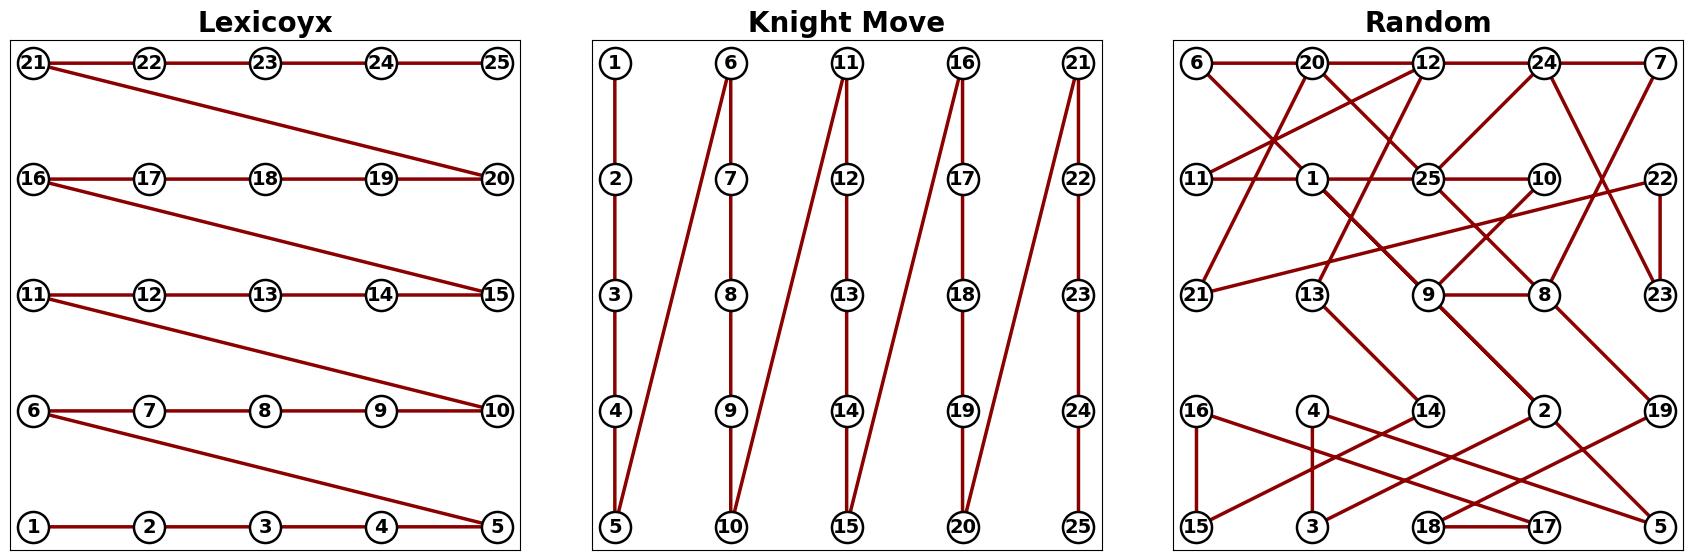

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import graphical_sampling as gs

# =========================================================
# CREATE PERFECT 4x4 GRID POPULATION
# =========================================================
M=5
x = np.repeat(np.arange(M), M)
y = np.tile(np.arange(M)[::-1], M)


coords = np.column_stack([
    x,
    y
]).astype(float)

N = len(coords)
n = 16

# equal inclusion probabilities
pik = np.repeat(n / N, N)

# fake variable
z = np.arange(N)

df = pd.DataFrame({
    'coord_x': coords[:, 0],
    'coord_y': coords[:, 1],
    'pik_ep': pik,
    'z': z
})

# =========================================================
# POPULATION
# =========================================================
pop = gs.Population(
    coords,
    pik,
    n=n,
    variable=z
)

# =========================================================
# STRATEGIES
# =========================================================
strategies = [
    'lexicoYX',
    'snake_move',
    'random'
]

# =========================================================
# FIGURE
# =========================================================
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    gridspec_kw={'wspace': 0.03}
)

# =========================================================
# MAIN LOOP
# =========================================================
for ax, strategy in zip(axes, strategies):

    # -----------------------------------------------------
    # ORDER
    # -----------------------------------------------------
    order_idx = gs.Order(pop)._get_strategy_order(
        coords,
        strategy=strategy,
        topological=True,
        grid_dims=(M, M)
    )

    ordered_coords = coords[order_idx]

    # -----------------------------------------------------
    # CONNECTION PATH
    # -----------------------------------------------------
    ax.plot(
        ordered_coords[:, 0],
        ordered_coords[:, 1],
        color='darkred',
        linewidth=2.5,
        zorder=1
    )

    # -----------------------------------------------------
    # POINTS
    # -----------------------------------------------------
    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        s=500,
        color='white',
        edgecolors='black',
        linewidths=1.8,
        zorder=5
    )

    # -----------------------------------------------------
    # LABELS
    # -----------------------------------------------------
    for rank, idx in enumerate(order_idx):

        cx, cy = coords[idx]

        ax.text(
            cx,
            cy,
            str(rank + 1),
            fontsize=14,
            fontweight='bold',
            ha='center',
            va='center',
            zorder=10
        )

    # -----------------------------------------------------
    # STYLE
    # -----------------------------------------------------
    ax.set_title(
        strategy.replace('_', ' ').title(),
        fontsize=20,
        fontweight='bold'
    )

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_aspect('equal')

# =========================================================
# FINAL LAYOUT
# =========================================================
plt.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.90,
    bottom=0.05,
    wspace=0.02
)

plt.show()